In [1]:
library(tidyverse)
library(tidygraph)
library(ggraph)

── Attaching core tidyverse packages ──────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘tidygraph’


The following object is masked from ‘package:stats’:

    filter




In [2]:
scMEGA_res_filtered <- read.csv('data/scMEGA/scMEGA_filtered_valid.csv')

In [3]:
scMEGA_res_filtered_more <- scMEGA_res_filtered[abs(scMEGA_res_filtered$correlation)>0.75,]
scMEGA_res_filtered_more <- scMEGA_res_filtered_more[!(scMEGA_res_filtered_more$tf %in% c('Foxo3','Lhx3')),]

In [4]:
nodes_tf <- scMEGA_res_filtered_more %>% 
  select(name = tf, z_score = tf_z_score) %>% 
  distinct() %>% 
  mutate(type = "TF")

nodes_gene <- scMEGA_res_filtered_more %>% 
  select(name = gene, z_score = gene_z_score) %>% 
  distinct() %>% 
  mutate(type = "Gene")

node_list <- bind_rows(nodes_tf, nodes_gene) %>%
  group_by(name) %>%
  summarise(z_score = mean(z_score), type = first(type))

edge_list <- scMEGA_res_filtered_more %>% select(from = tf, to = gene, correlation)

graph <- tbl_graph(nodes = node_list, edges = edge_list, directed = TRUE)

In [5]:
graph <- graph %>%
  activate(edges) %>%
  mutate(reg_type = factor(ifelse(correlation > 0, "pos", "neg"), 
                          levels = c("pos", "neg")))

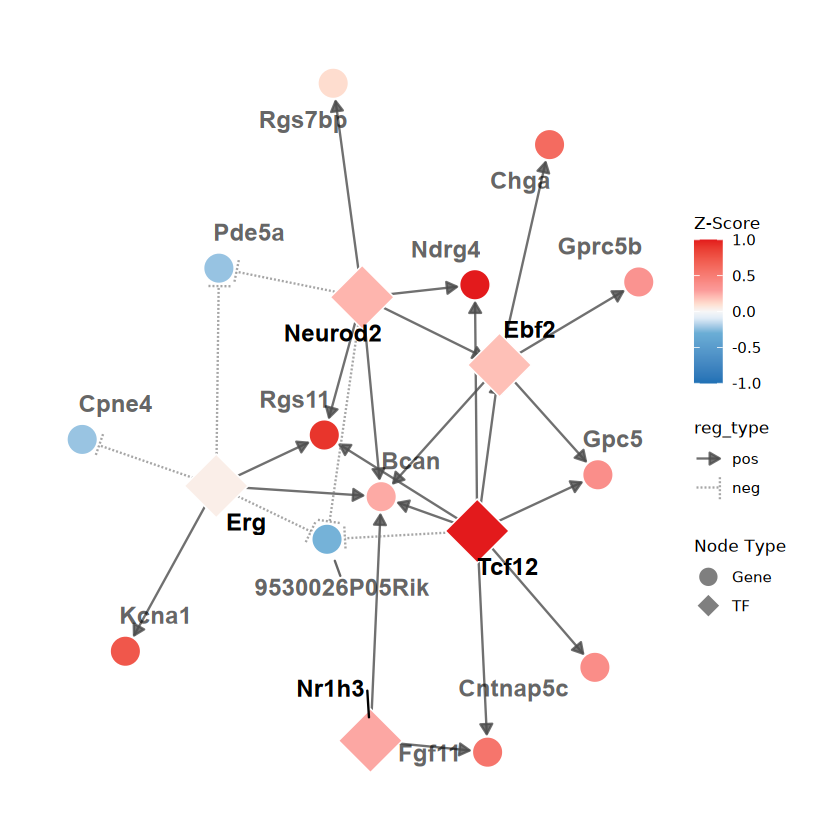

In [6]:
arrow_positive <- arrow(length = unit(2.5, 'mm'), type = "closed")
arrow_negative <- arrow(length = unit(2.5, 'mm'), type = "open", ends = "last", angle = 90)

vibrant_soft_palette <- c(
  "#2171b5", "#6baed6", "#deebf7",
  "#f7f7f7",
  "#fee0d2", "#fb9a99", "#e31a1c"
)
edge_pos_col <- "#4D4D4D"
edge_neg_col <- "#808080"

ggraph(graph, layout = 'stress') + 
  
  geom_edge_link(
    aes(filter = reg_type == "pos", linetype = reg_type),
    arrow = arrow_positive,
    end_cap = circle(3.8, 'mm'), 
    alpha = 0.8, color = edge_pos_col
  ) +

  geom_edge_link(
    aes(filter = reg_type == "neg", linetype = reg_type),
    arrow = arrow_negative,
    end_cap = circle(3.8, 'mm'),
    alpha = 0.7, color = edge_neg_col
  ) +

  geom_node_point(
    aes(shape = type, fill = z_score, size = type), 
    color = "white", stroke = 0.5
  ) +
  
  geom_node_text(
    aes(label = name, alpha = type), 
    size = 5,
    repel = TRUE,
    fontface = "bold",
    point.padding = unit(1.5, "lines"),
    box.padding = unit(1, "lines"),
    force = 10,
    show.legend = FALSE
  ) +
  
  scale_size_manual(
    values = c("TF" = 14, "Gene" = 8), 
    name = "Node Type", guide = "none"
  ) +
  
  scale_alpha_manual(values = c("TF" = 1, "Gene" = 0.6), guide = "none") +
  
  scale_fill_gradientn(
    colors = vibrant_soft_palette,
    values = scales::rescale(c(-1, -0.3, -0.1, 0, 0.1, 0.3, 1)), 
    limits = c(-1, 1), 
    oob = scales::squish,
    name = "Z-Score"
  ) +

  scale_linetype_manual(
    values = c("solid", "dashed"), 
    labels = c("> 0", "< 0"),
    name = "Correlation"
  ) +

  scale_shape_manual(values = c("TF" = 23, "Gene" = 21), name = "Node Type") + 

  guides(
    shape = guide_legend(override.aes = list(size = 5, fill = "grey50")),
    linetype = guide_legend(override.aes = list(color = "black", lwd = 1)),
    fill = guide_colorbar(order = 3)
  ) +

  theme_graph(base_family = "sans") +
  theme(
    legend.position = "right",
    plot.title = element_text(hjust = 0.5, size = 16),
    legend.title = element_text(size = 10)
  )